<a href="https://colab.research.google.com/github/gs0232/ml-a2-hanseg/blob/main/notebooks/a2_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1
![ -d /content/ml-a2-hanseg ] || git clone https://github.com/gs0232/ml-a2-hanseg.git /content/ml-a2-hanseg
%cd /content/ml-a2-hanseg
!git pull -q
!pip install -q SimpleITK

Cloning into '/content/ml-a2-hanseg'...
remote: Enumerating objects: 256, done.
remote: Counting objects: 100% (256/256), done.
remote: Compressing objects: 100% (165/165), done.
remote: Total 256 (delta 122), reused 179 (delta 64), pack-reused 0 (from 0)
Receiving objects: 100% (256/256), 617.80 KiB | 4.04 MiB/s, done.
Resolving deltas: 100% (122/122), done.
/content/ml-a2-hanseg
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 16.1 MB/s eta 0:00:00


In [2]:
# 2: every import, in one place — so later cells can run without the ones above

import importlib
import sys
import glob
import os
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
import torch


# --- Colab caches imported modules. After a !git pull the file on disk has
# --- changed but the module object in memory has not, so a plain
# --- `from src.viz import plot_loss` silently hands you yesterday's function.
# --- This reloads them in dependency order: a module that imports from another
# --- has to be reloaded AFTER the one it imports from, or it keeps holding the
# --- old function objects.
SRC_MODULES = ["src.data", "src.dataset", "src.loader", "src.model",
               "src.losses", "src.metrics", "src.train", "src.baselines",
               "src.viz", "src.experiment"]


def reload_src():
    """Call this after every !git pull, and at the top of any cell that has
    just had its source file edited. Cheap, and safe to call twice."""
    for name in SRC_MODULES:
        if name in sys.modules:
            importlib.reload(sys.modules[name])


import src.data
reload_src()

from src.data import (TARGET_FILES, case_files, load_case, preprocess_case,
                      resample, window, build_label, head_centre, crop_to)
from src.loader import make_loaders
from src.model import UNet2D
from src.train import fit, predict_case

print("src modules reloaded, targets:", TARGET_FILES)

src modules reloaded, targets: ['Cochlea_L', 'Cochlea_R', 'Parotid_L', 'Parotid_R']


In [3]:
# 3: cache location. Always local (fast, and self-contained for the assessor).
#    Drive is only my own backup so I can skip preprocessing next session.

USE_DRIVE = True            # <<< set False before submitting

CACHE = "/content/cache"
DRIVE_CACHE = "/content/drive/MyDrive/ml-a2-cache"
os.makedirs(CACHE, exist_ok=True)

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    if os.path.isdir(DRIVE_CACHE):
        n = 0
        for f in glob.glob(os.path.join(DRIVE_CACHE, "*.npz")):
            dst = os.path.join(CACHE, os.path.basename(f))
            if not os.path.exists(dst):
                shutil.copy2(f, dst)
                n += 1
        print(f"restored {n} case(s) from Drive")

print(len(glob.glob(os.path.join(CACHE, '*.npz'))), "case(s) in the local cache")

Mounted at /content/drive
restored 42 case(s) from Drive
42 case(s) in the local cache


---
## Data preparation

Everything from here down to the cache only needs running when the **preprocessing
changes**. Once `case_XX.npz` files exist (locally or restored from Drive in cell 3),
skip straight past this section to the model work.

In [ ]:
# 4: download HaN-Seg Dataset to Google Colab machine

!wget -c -O /content/HaN-Seg.zip "https://zenodo.org/records/7442914/files/HaN-Seg.zip?download=1"
!ls -1h /content/HaN-Seg.zip
!md5sum /content/HaN-Seg.zip

--2026-09-08 07:34:47--  https://zenodo.org/records/7442914/files/HaN-Seg.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 188.185.43.153, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4938848306 (4.6G) [application/octet-stream]
Saving to: ‘/content/HaN-Seg.zip’

/content/HaN-Seg.zi 100%[===================>]   4.60G  1.70MB/s    in 41m 14s 

2026-09-08 08:16:01 (1.90 MB/s) - ‘/content/HaN-Seg.zip’ saved [4938848306/4938848306]

/content/HaN-Seg.zip
c3d3070de3034933a63031b73b9cf0fc  /content/HaN-Seg.zip


In [ ]:
# 5: Unzip and find Dataset

!unzip -q /content/HaN-Seg.zip -d /content/
!find /content -maxdepth 3 -type d -name "case_01"

/content/HaN-Seg/set_1/case_01


In [ ]:
# 6: point at the data and see what one case folder holds

ROOT = "/content/HaN-Seg/set_1"

cases = sorted(glob.glob(os.path.join(ROOT, "case_*")))
print(len(cases), "cases found")

for f in sorted(os.listdir(cases[0])):
    print(" ", f)

42 cases found
  case_01_IMG_CT.nrrd
  case_01_IMG_MR_T1.nrrd
  case_01_OAR_A_Carotid_L.seg.nrrd
  case_01_OAR_A_Carotid_R.seg.nrrd
  case_01_OAR_Arytenoid.seg.nrrd
  case_01_OAR_Bone_Mandible.seg.nrrd
  case_01_OAR_Brainstem.seg.nrrd
  case_01_OAR_BuccalMucosa.seg.nrrd
  case_01_OAR_Cavity_Oral.seg.nrrd
  case_01_OAR_Cochlea_L.seg.nrrd
  case_01_OAR_Cochlea_R.seg.nrrd
  case_01_OAR_Cricopharyngeus.seg.nrrd
  case_01_OAR_Esophagus_S.seg.nrrd
  case_01_OAR_Eye_AL.seg.nrrd
  case_01_OAR_Eye_AR.seg.nrrd
  case_01_OAR_Eye_PL.seg.nrrd
  case_01_OAR_Eye_PR.seg.nrrd
  case_01_OAR_Glnd_Lacrimal_L.seg.nrrd
  case_01_OAR_Glnd_Lacrimal_R.seg.nrrd
  case_01_OAR_Glnd_Submand_L.seg.nrrd
  case_01_OAR_Glnd_Submand_R.seg.nrrd
  case_01_OAR_Glnd_Thyroid.seg.nrrd
  case_01_OAR_Glottis.seg.nrrd
  case_01_OAR_Larynx_SG.seg.nrrd
  case_01_OAR_Lips.seg.nrrd
  case_01_OAR_OpticChiasm.seg.nrrd
  case_01_OAR_OpticNrv_L.seg.nrrd
  case_01_OAR_OpticNrv_R.seg.nrrd
  case_01_OAR_Parotid_L.seg.nrrd
  case_01_OAR_Pa

42 patients with 32 filnames:

- 1x _IMG_CT.nrrd
- 1x _IMG_MR_T1.nrrd
- 30x Masks called _OAR_<name>.seg.nrrd
  - case_01_OAR_Cochlea_L.seg.nrrd
  - case_01_OAR_Cochlea_R.seg.nrrd
  - case_01_OAR_Parotid_L.seg.nrrd
  - case_01_OAR_Parotid_R.seg.nrrd

In [ ]:
# 7: open CT and look at the numbers

import src.data
importlib.reload(src.data)
from src.data import load_case, case_files, resample, window, TARGET_FILES

ct, masks = load_case(cases[0])

print("loaded     :", os.path.basename(cases[0]))
print("CT size    :", ct.GetSize())
print("CT spacing :", ct.GetSpacing())
for name, m in masks.items():
    print(f"  {name:12s} {int(sitk.GetArrayFromImage(m).sum())} voxels")

loaded     : case_01
CT size    : (1024, 1024, 202)
CT spacing : (0.5576171875, 0.5576171875, 2.0)
  Cochlea_L    108 voxels
  Cochlea_R    91 voxels
  Parotid_L    31858 voxels
  Parotid_R    26545 voxels


In [ ]:
# 8: proves load_case reads the case it was given.
#    The first version globbed inside case_dir and always returned cases[0],
#    so every case silently loaded case_01. Two different filenames = fixed.

print(os.path.basename(case_files(cases[0])["CT"]))
print(os.path.basename(case_files(cases[1])["CT"]))

case_01_IMG_CT.nrrd
case_02_IMG_CT.nrrd


In [ ]:
# 9
before = int((sitk.GetArrayFromImage(masks["Cochlea_L"]) > 0).sum())
vox = float(np.prod(ct.GetSpacing()))

m1 = resample(masks["Cochlea_L"], (1.0, 1.0, 1.0), is_mask=True)
after = int((sitk.GetArrayFromImage(m1) > 0).sum())

# catches when new cube would be placed in between the original boxes, which would be wrong (so when LinInt would be 0.4 -> doesn exist because masks hold classes (integers), not quantities (floats). The new cube should be placed where the original box was.

print(f"before : {before:5d} voxels x {vox:.3f} mm^3 = {before * vox:7.1f} mm^3")
print(f"after  : {after:5d} voxels x 1.000 mm^3 = {after:7.1f} mm^3")

before :   108 voxels x 0.622 mm^3 =    67.2 mm^3
after  :    66 voxels x 1.000 mm^3 =    66.0 mm^3


In [ ]:
# 10: what happens with the WRONG interpolator on a mask.
#     Linear interpolation averages neighbouring labels, so it invents values
#     like 0.5 between a 0 and a 1 — a voxel that is half cochlea, which does
#     not exist. Compare this count with the correct one in cell 9.

bad = resample(masks["Cochlea_L"], (1.0, 1.0, 1.0), is_mask=False)
print("is_mask=False ->", int((sitk.GetArrayFromImage(bad) > 0).sum()), "voxels")
print("is_mask=True  -> ", after, "voxels   (from cell 9)")

# RESULT: ______ voxels vs ______ voxels  -> note this in journal/log.md

is_mask=False -> 38 voxels
is_mask=True  ->  66 voxels   (from cell 9)


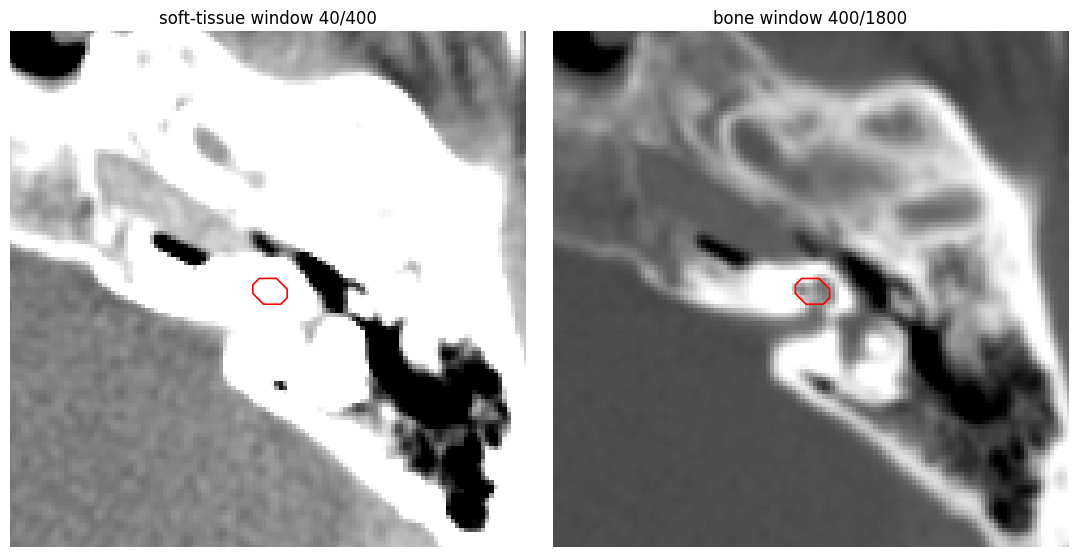

In [ ]:
# 11: Look at data

import matplotlib.pyplot as plt

arr  = sitk.GetArrayFromImage(ct)                        # (z, y, x), Hounsfield units
coch = sitk.GetArrayFromImage(masks["Cochlea_L"]) > 0

z = int(coch.sum(axis=(1, 2)).argmax())                  # slice with the most cochlea
ys, xs = np.where(coch[z])
cy, cx = int(ys.mean()), int(xs.mean())

soft = window(arr[z],  40,  400)      # soft-tissue window -> shows the parotid
bone = window(arr[z], 400, 1800)      # bone window        -> shows the temporal bone

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
for a, (img, title) in zip(ax, [(soft, "soft-tissue window 40/400"),
                                (bone, "bone window 400/1800")]):
    a.imshow(img, cmap="gray", vmin=0, vmax=1)
    a.contour(coch[z], levels=[0.5], colors="red", linewidths=1.2)
    a.set_xlim(cx - 60, cx + 60)
    a.set_ylim(cy + 60, cy - 60)
    a.set_title(title)
    a.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# 12: preprocess and cache. Start with N_CASES = 1, check the output, then 20.

N_CASES = 42                 # <<< set to 20 once one case looks right

t0 = time.time()
for i, case_dir in enumerate(cases[:N_CASES]):
    cid = os.path.basename(case_dir)          # case_dir = full path, cid = "case_01"
    out_path = os.path.join(CACHE, f"{cid}.npz")
    if os.path.exists(out_path):
        print(f"[{i+1:2d}/{N_CASES}] {cid} cached already")
        continue
    img, lab, keep = preprocess_case(case_dir, keep_all=True)
    np.savez_compressed(out_path, img=img, lab=lab, slices=keep)
    print(f"[{i+1:2d}/{N_CASES}] {cid}  img{img.shape}  "
          f"{os.path.getsize(out_path)/1e6:5.1f} MB  {time.time()-t0:4.0f}s")

[ 1/42] case_01 cached already
[ 2/42] case_02 cached already
[ 3/42] case_03 cached already
[ 4/42] case_04 cached already
[ 5/42] case_05 cached already
[ 6/42] case_06 cached already
[ 7/42] case_07 cached already
[ 8/42] case_08 cached already
[ 9/42] case_09 cached already
[10/42] case_10 cached already
[11/42] case_11 cached already
[12/42] case_12 cached already
[13/42] case_13 cached already
[14/42] case_14 cached already
[15/42] case_15 cached already
[16/42] case_16 cached already
[17/42] case_17 cached already
[18/42] case_18 cached already
[19/42] case_19 cached already
[20/42] case_20 cached already


/content/ml-a2-hanseg/src/data.py:218: UserWarning: case_21: crop lost 306 of 62232 label voxels
  warnings.warn(f"{os.path.basename(case_dir)}: crop lost "


[21/42] case_21  img(430, 2, 256, 256)   15.6 MB    25s
[22/42] case_22  img(396, 2, 256, 256)   16.8 MB    36s
[23/42] case_23  img(370, 2, 256, 256)   11.3 MB    53s
[24/42] case_24  img(374, 2, 256, 256)   12.6 MB    72s
[25/42] case_25  img(392, 2, 256, 256)   13.7 MB    92s
[26/42] case_26  img(404, 2, 256, 256)   17.4 MB   113s
[27/42] case_27  img(400, 2, 256, 256)   14.2 MB   130s
[28/42] case_28  img(646, 2, 256, 256)   28.3 MB   166s
[29/42] case_29  img(466, 2, 256, 256)   15.4 MB   189s


/content/ml-a2-hanseg/src/data.py:218: UserWarning: case_30: crop lost 288 of 82736 label voxels
  warnings.warn(f"{os.path.basename(case_dir)}: crop lost "


[30/42] case_30  img(428, 2, 256, 256)   14.6 MB   209s
[31/42] case_31  img(370, 2, 256, 256)   13.6 MB   218s


...

[35/42] case_35  img(412, 2, 256, 256)   15.3 MB   300s
[36/42] case_36  img(378, 2, 256, 256)   12.3 MB   316s


/content/ml-a2-hanseg/src/data.py:218: UserWarning: case_37: crop lost 38 of 51012 label voxels
  warnings.warn(f"{os.path.basename(case_dir)}: crop lost "


[37/42] case_37  img(372, 2, 256, 256)   11.6 MB   331s
[38/42] case_38  img(408, 2, 256, 256)   11.7 MB   346s


/content/ml-a2-hanseg/src/data.py:218: UserWarning: case_39: crop lost 1886 of 107332 label voxels
  warnings.warn(f"{os.path.basename(case_dir)}: crop lost "


[39/42] case_39  img(404, 2, 256, 256)   15.7 MB   364s
[40/42] case_40  img(378, 2, 256, 256)   13.1 MB   380s
[41/42] case_41  img(394, 2, 256, 256)   12.9 MB   395s
[42/42] case_42  img(410, 2, 256, 256)   15.1 MB   416s


In [ ]:
# 13: copy anything new into Drive, so next session starts from cell 3

if USE_DRIVE:
    os.makedirs(DRIVE_CACHE, exist_ok=True)
    n = 0
    for f in sorted(glob.glob(os.path.join(CACHE, "*.npz"))):
        dst = os.path.join(DRIVE_CACHE, os.path.basename(f))
        if not os.path.exists(dst):
            shutil.copy2(f, dst)
            n += 1
    print(f"copied {n} new file(s) to Drive")
    !du -sh {CACHE} {DRIVE_CACHE}

copied 22 new file(s) to Drive
593M	/content/cache
593M	/content/drive/MyDrive/ml-a2-cache


In [ ]:
# 14: check every cached case, not just the first one

files = sorted(glob.glob(os.path.join(CACHE, "*.npz")))
print(f"{'case':10s} {'img shape':22s} {'labels':12s}  " +
      "  ".join(f"{n[:9]:>9s}" for n in TARGET_FILES))
for f in files:
    d = np.load(f)
    counts = [int((d["lab"] == i).sum()) for i in range(1, 5)]
    print(f"{os.path.basename(f)[:-4]:10s} {str(d['img'].shape):22s} "
          f"{str(np.unique(d['lab'])):12s}  " + "  ".join(f"{c:9d}" for c in counts))
    if 0 in counts:
        print("   ^^ a structure has zero voxels — the crop cut it off")

case       img shape              labels        Cochlea_L  Cochlea_R  Parotid_L  Parotid_R
case_01    (404, 2, 256, 256)     [0 1 2 3 4]          66         56      19862      16590
case_02    (408, 2, 256, 256)     [0 1 2 3 4]         106         90      31452      34092
case_03    (388, 2, 256, 256)     [0 1 2 3 4]          68         84      17798      18002
case_04    (368, 2, 256, 256)     [0 1 2 3 4]          66         84      17556      20580
case_05    (364, 2, 256, 256)     [0 1 2 3 4]          68         64      29018      26502
case_06    (423, 2, 256, 256)     [0 1 2 3 4]         270        270      34392      33582
case_07    (396, 2, 256, 256)     [0 1 2 3 4]         120        114      21423      22350
case_08    (405, 2, 256, 256)     [0 1 2 3 4]         177        171      28053      35499
case_09    (348, 2, 256, 256)     [0 1 2 3 4]          96         63      25902      19773
case_10    (429, 2, 256, 256)     [0 1 2 3 4]          87         63      29178      31233

In [ ]:
# 15: which structure does the crop clip?

for cid in ["case_05", "case_12", "case_18", "case_20", "case_21", "case_30", "case_32", "case_35", "case_37", "case_39"]:
    case_dir = os.path.join(ROOT, cid)
    paths = case_files(case_dir)
    hu = sitk.GetArrayFromImage(resample(sitk.ReadImage(paths["CT"]), (1.0, 1.0, 1.0)))
    masks = {n: sitk.GetArrayFromImage(
                 resample(sitk.ReadImage(paths[n]), (1.0, 1.0, 1.0), is_mask=True)) > 0
             for n in TARGET_FILES}
    lab = build_label(masks)
    cy, cx = head_centre(hu)
    lab_c = crop_to(lab, cy, cx, 256, pad_value=0)
    print(cid)
    for i, n in enumerate(TARGET_FILES, 1):
        b, a = int((lab == i).sum()), int((lab_c == i).sum())
        if b != a:
            print(f"   {n:12s} {b:6d} -> {a:6d}   lost {b - a} ({100 * (b - a) / b:.1f}%)")

case_05
   Parotid_L     29036 ->  29018   lost 18 (0.1%)
case_12
   Parotid_L     25815 ->  25581   lost 234 (0.9%)
case_18
   Parotid_L     49455 ->  47265   lost 2190 (4.4%)
   Parotid_R     46845 ->  46602   lost 243 (0.5%)
case_20
   Parotid_R     25830 ->  25449   lost 381 (1.5%)
case_21
   Parotid_L     32254 ->  31948   lost 306 (0.9%)
case_30
   Parotid_L     44244 ->  43956   lost 288 (0.7%)
case_32
   Parotid_L     28564 ->  28230   lost 334 (1.2%)
   Parotid_R     28878 ->  28752   lost 126 (0.4%)
case_35
   Parotid_L     44958 ->  44216   lost 742 (1.7%)
case_37
   Parotid_L     24834 ->  24798   lost 36 (0.1%)
   Parotid_R     25888 ->  25886   lost 2 (0.0%)
case_39
   Parotid_L     51288 ->  51270   lost 18 (0.0%)
   Parotid_R     55650 ->  53782   lost 1868 (3.4%)


---
## Model

Split, metrics, baselines, the U-Net, the losses and training go below here.
Everything in this section reads only the cached `.npz` files, so it runs after
cells 1-3 alone.

In [4]:
# 16: the frozen split
from src.dataset import cached_case_ids, load_or_make_split

ids = cached_case_ids(CACHE)
split = load_or_make_split("src/split.json", ids, seed=0, n_train=25, n_val=8)
for k in ("train", "val", "test"):
    print(f"{k:6s} {len(split[k]):2d}  {split[k]}")

train  25  ['case_01', 'case_02', 'case_03', 'case_04', 'case_05', 'case_10', 'case_11', 'case_12', 'case_18', 'case_19', 'case_21', 'case_22', 'case_23', 'case_24', 'case_25', 'case_27', 'case_28', 'case_29', 'case_31', 'case_33', 'case_37', 'case_38', 'case_39', 'case_40', 'case_41']
val     8  ['case_07', 'case_09', 'case_14', 'case_17', 'case_20', 'case_26', 'case_35', 'case_36']
test    9  ['case_06', 'case_08', 'case_13', 'case_15', 'case_16', 'case_30', 'case_32', 'case_34', 'case_42']


In [ ]:
# 17: the two baselines, on the test patients
import pandas as pd
from src.baselines import predict_all_background, predict_bone_threshold
from src.metrics import evaluate_case

rows = []
for cid in split["test"]:
    d = np.load(os.path.join(CACHE, f"{cid}.npz"))
    img, gt = d["img"], d["lab"]
    for name, pred in [("all_background", predict_all_background(img)),
                       ("bone_threshold", predict_bone_threshold(img))]:
        acc = float((pred == gt).mean())
        for r in evaluate_case(pred, gt, TARGET_FILES):
            r.update(case=cid, baseline=name, pixel_accuracy=acc)
            rows.append(r)

df = pd.DataFrame(rows)
print(df.groupby(["baseline", "structure"])[["dice", "hd95_mm", "sdice_1mm"]].mean().round(4))
print("\npixel accuracy of predicting background everywhere:",
      round(df[df.baseline == "all_background"].pixel_accuracy.mean(), 5))
if USE_DRIVE:
    df.to_csv(f"{DRIVE_CACHE}/baseline_results.csv", index=False)

                            dice   hd95_mm  sdice_1mm
baseline       structure                             
all_background Cochlea_L  0.0000       NaN        NaN
               Cochlea_R  0.0000       NaN        NaN
               Parotid_L  0.0000       NaN        NaN
               Parotid_R  0.0000       NaN        NaN
bone_threshold Cochlea_L  0.0011  199.0599     0.0018
               Cochlea_R  0.0000       NaN        NaN
               Parotid_L  0.0000       NaN        NaN
               Parotid_R  0.0000       NaN        NaN

pixel accuracy of predicting background everywhere: 0.9976


In [5]:
# 18: build the loaders and the model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, val_loader = make_loaders(CACHE, split, batch_size=8, augment=True)

print(f"{len(train_loader.dataset):5d} training slices (selected)")
print(f"{len(val_loader.dataset):5d} validation slices (all of them)")
print("class counts in training:", train_loader.dataset.class_counts())

model = UNet2D().to(device)
print(f"{model.n_parameters():,} parameters")
print("shape check:", tuple(model(torch.zeros(2, 2, 256, 256, device=device)).shape))

 3538 training slices (selected)
 3078 validation slices (all of them)
class counts in training: [230568530      3500      3732    646810    643796]
7,762,885 parameters
shape check: (2, 5, 256, 256)


In [ ]:
# 19: first real training run  (~35-45 min)
history, best = fit(model, train_loader, val_loader, device,
                    loss_name="compound", epochs=30, lr=1e-3)
model.load_state_dict(best)
torch.save(best, f"{DRIVE_CACHE}/unet_compound.pt")

epoch   0  loss 1.0682  Cochlea 0.000  Cochlea 0.000  Parotid 0.685  Parotid 0.682   mean 0.342  [58s]
epoch   1  loss 0.5353  Cochlea 0.000  Cochlea 0.000  Parotid 0.291  Parotid 0.020   mean 0.078  [117s]
epoch   2  loss 0.2804  Cochlea 0.000  Cochlea 0.000  Parotid 0.758  Parotid 0.747   mean 0.376  [176s]
epoch   3  loss 0.2703  Cochlea 0.000  Cochlea 0.000  Parotid 0.775  Parotid 0.768   mean 0.386  [235s]
epoch   4  loss 0.2630  Cochlea 0.000  Cochlea 0.000  Parotid 0.788  Parotid 0.779   mean 0.392  [294s]
epoch   5  loss 0.2579  Cochlea 0.000  Cochlea 0.000  Parotid 0.778  Parotid 0.743   mean 0.380  [353s]
epoch   6  loss 0.2557  Cochlea 0.000  Cochlea 0.000  Parotid 0.794  Parotid 0.780   mean 0.394  [412s]
epoch   7  loss 0.2523  Cochlea 0.000  Cochlea 0.000  Parotid 0.805  Parotid 0.801   mean 0.401  [471s]
epoch   8  loss 0.2548  Cochlea 0.000  Cochlea 0.000  Parotid 0.791  Parotid 0.773   mean 0.391  [530s]
epoch   9  loss 0.2471  Cochlea 0.000  Cochlea 0.000  Parotid 0.8

In [ ]:
# 20: the honest number — full 3D metrics on the 9 test patients
import pandas as pd
from src.metrics import evaluate_case

pd.DataFrame(history).to_csv(f"{DRIVE_CACHE}/history_compound.csv", index=False)

rows = []
for cid in split["test"]:
    pred, gt = predict_case(model, CACHE, cid, device)
    for r in evaluate_case(pred, gt, TARGET_FILES):
        r.update(case=cid, run="unet_compound")
        rows.append(r)

test_df = pd.DataFrame(rows)
test_df.to_csv(f"{DRIVE_CACHE}/test_compound.csv", index=False)
print(test_df.groupby("structure")[["dice", "hd95_mm", "hdmax_mm",
                                    "sdice_1mm", "sdice_2mm"]].mean().round(3))
print("\ncomplete misses:", int(test_df.missed.sum()), "of", len(test_df))

            dice  hd95_mm  hdmax_mm  sdice_1mm  sdice_2mm
structure                                                
Cochlea_L  0.000      NaN       NaN        NaN        NaN
Cochlea_R  0.000      NaN       NaN        NaN        NaN
Parotid_L  0.814    8.298    46.182      0.576      0.752
Parotid_R  0.823    5.093    34.076      0.586      0.773

complete misses: 18 of 36


In [ ]:
# 21: does the model have cochlea signal that argmax is discarding?
model.eval()
cid = split["test"][0]
d = np.load(f"{CACHE}/{cid}.npz")
img, gt = d["img"], d["lab"]

z = int((gt == 1).sum(axis=(1, 2)).argmax())        # slice with the most Cochlea_L
x = torch.from_numpy(img[z:z+1].astype(np.float32) / 255.0).to(device)
with torch.no_grad():
    prob = model(x).softmax(1)[0].cpu().numpy()      # (5, 256, 256)

m = gt[z] == 1
print(f"{cid}, slice {z}, {int(m.sum())} true Cochlea_L voxels")
for c, name in enumerate(["background"] + list(TARGET_FILES)):
    print(f"  mean p({name:11s}) at the true cochlea = {prob[c][m].mean():.4f}")
print(f"  max p(Cochlea_L) anywhere in this slice   = {prob[1].max():.4f}")
print(f"  voxels with p(Cochlea_L) > 0.10           = {int((prob[1] > 0.10).sum())}")

case_06, slice 278, 30 true Cochlea_L voxels
  mean p(background ) at the true cochlea = 1.0000
  mean p(Cochlea_L  ) at the true cochlea = 0.0000
  mean p(Cochlea_R  ) at the true cochlea = 0.0000
  mean p(Parotid_L  ) at the true cochlea = 0.0000
  mean p(Parotid_R  ) at the true cochlea = 0.0000
  max p(Cochlea_L) anywhere in this slice   = 0.0000
  voxels with p(Cochlea_L) > 0.10           = 0


---
## Experiments

Everything below compares runs rather than producing one. The figures are
written into Drive, not into the repo checkout, because the checkout
disappears when the Colab runtime does.

In [6]:
# 22: where run outputs live, and seed Drive from anything already committed
#
# CSV_DIR and FIG_DIR point at DRIVE, not at the checkout. /content/ is deleted
# the moment the runtime is recycled — an idle disconnect is enough — and a
# training result that only exists there is a result you do not have.
reload_src()          # pick up any edits pulled in cell 1
import glob
import shutil
import os
from src.viz import plot_loss, plot_val_dice

CSV_DIR = f"{DRIVE_CACHE}/experiments"
FIG_DIR = f"{DRIVE_CACHE}/figures"
os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# anything committed to experiments/ in the repo is copied up to Drive, so a
# CSV recovered on your Mac becomes visible to every cell below
for src in glob.glob("experiments/*.csv"):
    dst = f"{CSV_DIR}/{os.path.basename(src)}"
    if not os.path.exists(dst):
        shutil.copy(src, dst)
        print("seeded", os.path.basename(src))

print("\nCSVs   ->", CSV_DIR)
for f in sorted(os.listdir(CSV_DIR)):
    print("   ", f)
print("figures->", FIG_DIR)

seeded history_ce.csv
seeded metrics_1.csv
seeded results.csv
seeded history_tversky.csv
seeded preprocessing_1.csv
seeded crop_losses.csv
seeded history_compound.csv
seeded train_run_1.csv
seeded baseline_9cases.csv
seeded baseline_4cases.csv
seeded history_dice.csv

CSVs   -> /content/drive/MyDrive/ml-a2-cache/experiments
    baseline_4cases.csv
    baseline_9cases.csv
    crop_losses.csv
    history_ce.csv
    history_compound.csv
    history_dice.csv
    history_tversky.csv
    metrics_1.csv
    preprocessing_1.csv
    results.csv
    train_run_1.csv
figures-> /content/drive/MyDrive/ml-a2-cache/figures


In [ ]:
# 23: the five runs.  ~3.5 h on a T4.
#
# Runs 1-4 change ONLY the loss: same cached slices, same split, same seed,
# same optimiser, same schedule, same epoch count. Run 5 changes the training
# MIX instead and is reported separately.
#
# Safe to re-run. A run whose test CSV already exists in CSV_DIR is loaded, not
# repeated, so if this dies partway you just run the cell again and it picks up
# where it stopped. History and best weights are written to Drive after EVERY
# epoch, so even a run killed mid-way leaves what it had.
#
# Keep the runtime alive: leave the tab open and visible, and stop your Mac
# sleeping (`caffeinate -dims` in Terminal, Ctrl-C when done).
reload_src()          # pick up any edits pulled in cell 1
import pandas as pd
from src.experiment import run_one, RUNS

# An epoch takes about 60 s on a T4 and roughly half an hour on CPU, so five
# runs on CPU is about a week. Refuse rather than start something that cannot
# finish. Cells 27 and 28 are inference only and DO work on CPU.
if device.type != "cuda":
    raise RuntimeError(
        "No GPU on this runtime — training would take days.\n"
        "Runtime > Change runtime type > T4 GPU. If Colab says the usage limit "
        "is reached, run cells 27 and 28 instead (they work on CPU) and come "
        "back to this one when a GPU is available.")

test_frames = []

for i, cfg in enumerate(RUNS, start=1):
    hist_df, test_df = run_one(cache_dir=CACHE, split=split, device=device,
                               weights_dir=DRIVE_CACHE, csv_dir=CSV_DIR,
                               fig_dir=FIG_DIR, epochs=30,
                               run_index=i, n_runs=len(RUNS), **cfg)
    test_frames.append(test_df)

all_test = pd.concat(test_frames, ignore_index=True)
all_test.to_csv(f"{CSV_DIR}/test_all_runs.csv", index=False)
print("\nsaved", f"{CSV_DIR}/test_all_runs.csv")

In [ ]:
# 24: the two cross-run figures, plus the table they summarise
reload_src()          # pick up any edits pulled in cell 1
import pandas as pd
from src.viz import plot_val_curves, plot_run_comparison

names = [c["name"] for c in RUNS]

plot_val_curves({n: f"{CSV_DIR}/history_{n}.csv" for n in names},
                f"{FIG_DIR}/fig_all_runs_val_dice.png")
plot_run_comparison(f"{CSV_DIR}/test_all_runs.csv",
                    f"{FIG_DIR}/fig_all_runs_test_dice.png", order=names)

all_test = pd.read_csv(f"{CSV_DIR}/test_all_runs.csv")
table = (all_test.groupby(["run", "structure"])
         [["dice", "hd95_mm", "hdmax_mm", "sdice_1mm"]].mean().round(3))
table.to_csv(f"{CSV_DIR}/summary_by_run.csv")
print(table.to_string())
print("\ncomplete misses per run:")
print(all_test.groupby("run").missed.sum().to_string())

In [ ]:
# 25: split the test set by acquisition batch.
#
# Cochlea contour volume nearly doubles from cases 01-20 to 21-42
# (p = 2.3e-08). Five test patients come from the first group and four from
# the second. If a run scores differently on the two, that is the label batch
# effect showing up in the results, not a property of the model.
old = [f"case_{i:02d}" for i in range(1, 21)]
all_test["batch"] = all_test.case.apply(lambda c: "cases 01-20" if c in old
                                        else "cases 21-42")
by_batch = (all_test.groupby(["run", "batch", "structure"]).dice.mean()
            .round(3).unstack())
by_batch.to_csv(f"{CSV_DIR}/test_by_batch.csv")
print(by_batch.to_string())

In [ ]:
# 26: pull the evidence onto your Mac.
#
# Everything is already safe on Drive — this just bundles the CSVs and figures
# (NOT the cache or the weights, which are hundreds of megabytes) and downloads
# one zip into your Downloads folder. Unpack it into the repo's experiments/
# and figures/ and commit: the CSVs are what the report is built from.
import os, shutil
from google.colab import files

STAGE = "/content/a2_results"
shutil.rmtree(STAGE, ignore_errors=True)
shutil.copytree(CSV_DIR, f"{STAGE}/experiments")
shutil.copytree(FIG_DIR, f"{STAGE}/figures")

zip_path = shutil.make_archive(STAGE, "zip", root_dir=STAGE)
print(f"{os.path.getsize(zip_path) / 1e6:.1f} MB  ->  {zip_path}")
files.download(zip_path)

In [7]:
# 27: RECOVERY — rebuild a finished run's test CSV from weights saved in Drive.
#     Inference only: this WORKS ON CPU (~2 min per case instead of ~15 s).
#
# Run this BEFORE cell 23 when a run trained successfully but its CSVs were
# lost. It reloads <name>.pt, re-runs the nine test patients and writes
# test_<name>.csv — which is the file cell 23 checks to decide a run is done,
# so those runs will then be skipped instead of retrained. About a minute each.
#
# What it cannot recover is the epoch-by-epoch history: that only existed in
# the CSV. If you still have the printed epoch log in a Colab output, keep it —
# the training curves can be rebuilt from that text.
reload_src()
import os
import pandas as pd
import torch
from src.model import UNet2D
from src.train import predict_case
from src.metrics import evaluate_case

RECOVER = ["ce", "dice", "compound"]        # runs whose .pt survived in Drive

for name in RECOVER:
    pt = f"{DRIVE_CACHE}/{name}.pt"
    out = f"{CSV_DIR}/test_{name}.csv"
    if not os.path.exists(pt):
        print(f"[{name}] no weights in Drive — this one has to be retrained")
        continue
    if os.path.exists(out):
        print(f"[{name}] test CSV already present, nothing to do")
        continue
    model = UNet2D().to(device)
    model.load_state_dict(torch.load(pt, map_location=device))
    rows = []
    for k, cid in enumerate(split["test"], start=1):
        # printed per case: on CPU this takes a couple of minutes each, and a
        # cell that prints nothing for twenty minutes looks like a hung cell
        print(f"    {cid}  ({k}/{len(split['test'])})", flush=True)
        pred, gt = predict_case(model, CACHE, cid, device)
        for r in evaluate_case(pred, gt, list(TARGET_FILES)):
            r.update(case=cid, run=name)
            rows.append(r)
    df = pd.DataFrame(rows)
    df.to_csv(out, index=False)
    print(f"[{name}] rebuilt {out}")
    print(df.groupby("structure").dice.mean().round(3).to_string())

    case_06  (1/9)
    case_08  (2/9)
    case_13  (3/9)
    case_15  (4/9)
    case_16  (5/9)
    case_30  (6/9)
    case_32  (7/9)
    case_34  (8/9)
    case_42  (9/9)
[ce] rebuilt /content/drive/MyDrive/ml-a2-cache/experiments/test_ce.csv
structure
Cochlea_L    0.597
Cochlea_R    0.655
Parotid_L    0.777
Parotid_R    0.809
    case_06  (1/9)
    case_08  (2/9)
    case_13  (3/9)
    case_15  (4/9)
    case_16  (5/9)
    case_30  (6/9)
    case_32  (7/9)
    case_34  (8/9)
    case_42  (9/9)
[dice] rebuilt /content/drive/MyDrive/ml-a2-cache/experiments/test_dice.csv
structure
Cochlea_L    0.000
Cochlea_R    0.000
Parotid_L    0.802
Parotid_R    0.818
    case_06  (1/9)
    case_08  (2/9)
    case_13  (3/9)
    case_15  (4/9)
    case_16  (5/9)
    case_30  (6/9)
    case_32  (7/9)
    case_34  (8/9)
    case_42  (9/9)
[compound] rebuilt /content/drive/MyDrive/ml-a2-cache/experiments/test_compound.csv
structure
Cochlea_L    0.000
Cochlea_R    0.000
Parotid_L    0.817
Parotid_R    0.8

In [8]:
# 28: how much of the "compound" loss is actually cross-entropy?
#
# Runs 1 and 3 differ by one term, and they end three orders of magnitude
# apart: ce finishes at 0.0015, compound at 0.2040. If compound = ce + dice,
# the cross-entropy term is under 1% of it by the end — which would mean the
# compound loss is a Dice loss with a rounding error attached, and that is a
# claim worth measuring rather than inferring from two numbers.
#
# No training. Loads the compound run's weights, takes one batch, and prints
# both terms separately. Two minutes.
reload_src()
import torch
import torch.nn.functional as F
from src.model import UNet2D
from src.losses import dice_loss

model = UNet2D().to(device)
model.load_state_dict(torch.load(f"{DRIVE_CACHE}/compound.pt", map_location=device))
model.eval()

ce_vals, dice_vals = [], []
with torch.no_grad():
    for i, (x, y) in enumerate(train_loader):
        if i >= 20:
            break
        logits = model(x.to(device))
        t = y.to(device)
        ce_vals.append(F.cross_entropy(logits, t.long()).item())
        dice_vals.append(dice_loss(logits, t).item())

ce_m = sum(ce_vals) / len(ce_vals)
dc_m = sum(dice_vals) / len(dice_vals)
print(f"over {len(ce_vals)} training batches, at the compound run's best weights")
print(f"  cross-entropy term  {ce_m:.5f}")
print(f"  soft Dice term      {dc_m:.5f}")
print(f"  compound total      {ce_m + dc_m:.5f}")
print(f"  cross-entropy is {100 * ce_m / (ce_m + dc_m):.2f}% of the compound loss")

over 20 training batches, at the compound run's best weights
  cross-entropy term  0.00686
  soft Dice term      0.25366
  compound total      0.26052
  cross-entropy is 2.63% of the compound loss
